# Week 2 — SVM Task Classifier & Combined Evaluation

**Project:** AI-Powered Task Management System
**Prepared by:** Vijayasiva

**Goals**
1. Train a Linear SVM to predict the task `category` on the **shared stratified split** from `models/` (same rows as Naive Bayes)
2. Compare TF-IDF features against averaged Word2Vec document vectors
3. Tune `C` with GridSearchCV, using balanced class weights for the imbalanced classes
4. Evaluate with accuracy, precision, recall; produce the combined Naive Bayes vs. SVM comparison and a Week 3 recommendation

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

sns.set_style("whitegrid")

MODELS = "../models"
with open(f"{MODELS}/feature_manifest.json") as f:
    manifest = json.load(f)
print("Feature manifest:", json.dumps(manifest["tfidf"], indent=2)[:400])

Xtr_tfidf = joblib.load(f"{MODELS}/tfidf_train.joblib")
Xte_tfidf = joblib.load(f"{MODELS}/tfidf_test.joblib")
Xtr_w2v = joblib.load(f"{MODELS}/w2v_train.joblib")
Xte_w2v = joblib.load(f"{MODELS}/w2v_test.joblib")
y_train = joblib.load(f"{MODELS}/y_train.joblib")
y_test = joblib.load(f"{MODELS}/y_test.joblib")

print(f"TF-IDF train/test: {Xtr_tfidf.shape} / {Xte_tfidf.shape}")
print(f"Word2Vec train/test: {Xtr_w2v.shape} / {Xte_w2v.shape}")

Feature manifest: {
  "config_used": "unigram_bigram_default",
  "params": {
    "ngram_range": [
      1,
      2
    ],
    "min_df": 2,
    "max_features": 5000
  },
  "vocab_size": 1814,
  "files": [
    "tfidf_vectorizer.joblib",
    "tfidf_matrix.joblib",
    "tfidf_train.joblib",
    "tfidf_test.joblib"
  ]
}
TF-IDF train/test: (6400, 1814) / (1600, 1814)
Word2Vec train/test: (6400, 100) / (1600, 100)


## 1. Linear SVM on TF-IDF

`class_weight="balanced"` compensates for the class imbalance (Research ≈ 5–7%); `C` is tuned by 5-fold stratified cross-validation on macro-F1, the metric that weights small classes equally.

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_grid = {"C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_tfidf = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42),
    C_grid, scoring="f1_macro", cv=cv, n_jobs=-1,
)
grid_tfidf.fit(Xtr_tfidf, y_train)
print(f"Best C (TF-IDF): {grid_tfidf.best_params_['C']}  "
      f"(CV macro-F1 = {grid_tfidf.best_score_:.3f})")

Best C (TF-IDF): 0.01  (CV macro-F1 = 0.788)


In [3]:
preds_tfidf = grid_tfidf.best_estimator_.predict(Xte_tfidf)
acc_tfidf = accuracy_score(y_test, preds_tfidf)
rep_tfidf = classification_report(y_test, preds_tfidf, output_dict=True, zero_division=0)
print(f"Accuracy: {acc_tfidf:.3f}")
print(classification_report(y_test, preds_tfidf, digits=3, zero_division=0))

Accuracy: 0.815
               precision    recall  f1-score   support

      Bug Fix      0.942     0.835     0.885       387
   Deployment      0.651     0.910     0.759       166
Documentation      0.738     0.919     0.819       172
      Feature      0.955     0.851     0.900       328
  Maintenance      0.787     0.621     0.695       214
     Research      0.597     0.880     0.712       108
      Testing      0.864     0.733     0.793       225

     accuracy                          0.815      1600
    macro avg      0.791     0.821     0.795      1600
 weighted avg      0.838     0.815     0.818      1600



## 2. Linear SVM on Word2Vec Document Vectors

The dense Word2Vec vectors are standardized first (SVMs are scale-sensitive; TF-IDF is already normalized).

In [4]:
scaler = StandardScaler().fit(Xtr_w2v)
Xtr_w2v_s = scaler.transform(Xtr_w2v)
Xte_w2v_s = scaler.transform(Xte_w2v)

grid_w2v = GridSearchCV(
    LinearSVC(class_weight="balanced", random_state=42),
    C_grid, scoring="f1_macro", cv=cv, n_jobs=-1,
)
grid_w2v.fit(Xtr_w2v_s, y_train)
print(f"Best C (Word2Vec): {grid_w2v.best_params_['C']}  "
      f"(CV macro-F1 = {grid_w2v.best_score_:.3f})")

preds_w2v = grid_w2v.best_estimator_.predict(Xte_w2v_s)
acc_w2v = accuracy_score(y_test, preds_w2v)
rep_w2v = classification_report(y_test, preds_w2v, output_dict=True, zero_division=0)
print(f"Accuracy: {acc_w2v:.3f}")
print(classification_report(y_test, preds_w2v, digits=3, zero_division=0))

Best C (Word2Vec): 0.01  (CV macro-F1 = 0.789)
Accuracy: 0.810
               precision    recall  f1-score   support

      Bug Fix      0.947     0.832     0.886       387
   Deployment      0.654     0.910     0.761       166
Documentation      0.770     0.837     0.802       172
      Feature      0.955     0.851     0.900       328
  Maintenance      0.735     0.636     0.682       214
     Research      0.584     0.870     0.699       108
      Testing      0.833     0.756     0.793       225

     accuracy                          0.810      1600
    macro avg      0.783     0.813     0.789      1600
 weighted avg      0.830     0.810     0.814      1600



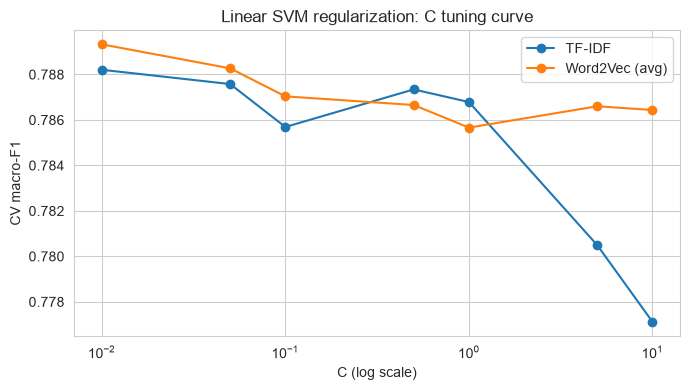

In [5]:
# Tuning curve: CV macro-F1 vs C for both feature sets
Cs = C_grid["C"]
plt.figure(figsize=(7, 4))
plt.plot(Cs, grid_tfidf.cv_results_["mean_test_score"], marker="o", label="TF-IDF")
plt.plot(Cs, grid_w2v.cv_results_["mean_test_score"], marker="o", label="Word2Vec (avg)")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("CV macro-F1")
plt.title("Linear SVM regularization: C tuning curve")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Naive Bayes on the Same Features (for a fair comparison)

The Naive Bayes notebook (04) tunes its own vectorizers; here we also fit NB on the **exact shared TF-IDF features** so the model comparison holds features and split constant.

In [6]:
grid_nb = GridSearchCV(
    MultinomialNB(), {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
    scoring="f1_macro", cv=cv, n_jobs=-1,
)
grid_nb.fit(Xtr_tfidf, y_train)
preds_nb = grid_nb.best_estimator_.predict(Xte_tfidf)
acc_nb = accuracy_score(y_test, preds_nb)
rep_nb = classification_report(y_test, preds_nb, output_dict=True, zero_division=0)
print(f"Best alpha: {grid_nb.best_params_['alpha']}  "
      f"(CV macro-F1 = {grid_nb.best_score_:.3f})")
print(f"Accuracy: {acc_nb:.3f}")

Best alpha: 0.01  (CV macro-F1 = 0.785)
Accuracy: 0.816


## 4. Combined Evaluation — Naive Bayes vs. SVM (shared split)

In [7]:
def row(name, features, rep, acc):
    return {"Model": name, "Features": features, "Accuracy": round(acc, 3),
            "Macro Precision": round(rep["macro avg"]["precision"], 3),
            "Macro Recall": round(rep["macro avg"]["recall"], 3),
            "Macro F1": round(rep["macro avg"]["f1-score"], 3),
            "Research Recall": round(rep.get("Research", {}).get("recall", float("nan")), 3)}

comparison = pd.DataFrame([
    row("Naive Bayes", "TF-IDF (shared)", rep_nb, acc_nb),
    row("Linear SVM", "TF-IDF (shared)", rep_tfidf, acc_tfidf),
    row("Linear SVM", "Word2Vec (avg)", rep_w2v, acc_w2v),
])
comparison

,Model,Features,Accuracy,Macro Precision,Macro Recall,Macro F1,Research Recall
0,Naive Bayes,TF-IDF (shared),0.816,0.788,0.811,0.797,0.778
1,Linear SVM,TF-IDF (shared),0.815,0.791,0.821,0.795,0.880
2,Linear SVM,Word2Vec (avg),0.810,0.783,0.813,0.789,0.870


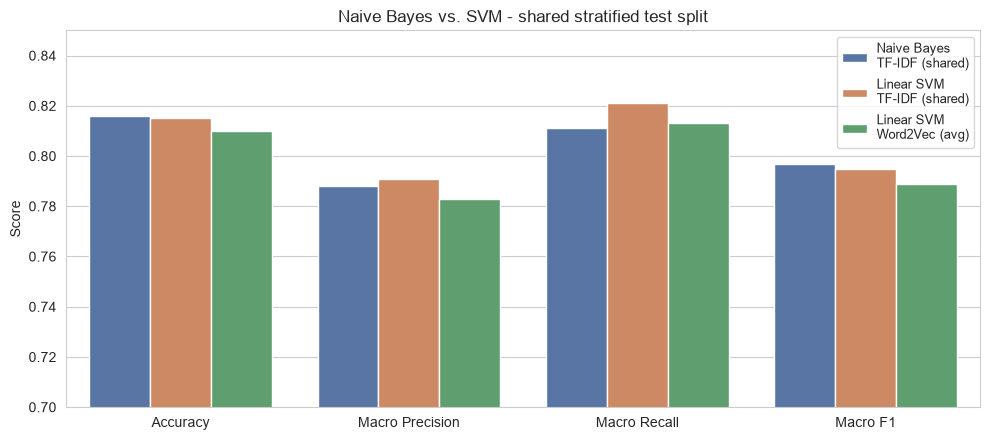

In [8]:
# Visual model comparison on the shared test split
metrics = ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
plot_df = comparison.assign(label=comparison["Model"] + "\n" + comparison["Features"]) \
                    .melt(id_vars="label", value_vars=metrics,
                          var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 4.5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="label", palette="deep")
plt.ylim(0.7, 0.85)
plt.title("Naive Bayes vs. SVM - shared stratified test split")
plt.ylabel("Score"); plt.xlabel("")
plt.legend(title="", fontsize=9)
plt.tight_layout()
plt.show()

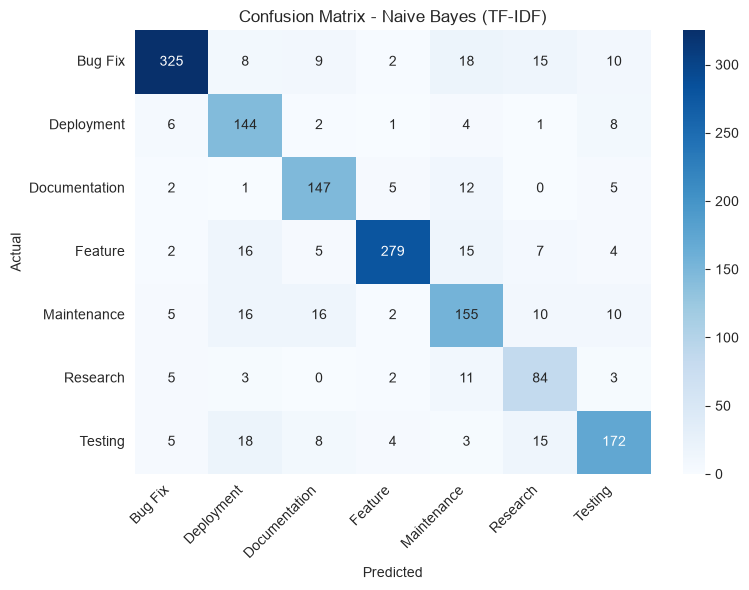

Best model by macro-F1: Naive Bayes (TF-IDF)


In [9]:
labels = sorted(pd.Series(y_test).unique())
best = max([("Linear SVM (TF-IDF)", preds_tfidf, rep_tfidf),
            ("Linear SVM (Word2Vec)", preds_w2v, rep_w2v),
            ("Naive Bayes (TF-IDF)", preds_nb, rep_nb)],
           key=lambda t: t[2]["macro avg"]["f1-score"])
best_name, best_preds, _ = best
cm = confusion_matrix(y_test, best_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(f"Best model by macro-F1: {best_name}")

In [10]:
joblib.dump(grid_tfidf.best_estimator_, f"{MODELS}/svm_tfidf.joblib")
comparison.to_csv(f"{MODELS}/week2_model_comparison.csv", index=False)
print("Saved svm_tfidf.joblib and week2_model_comparison.csv to models/")

Saved svm_tfidf.joblib and week2_model_comparison.csv to models/


## 5. Conclusions & Week 3 Recommendation

- Both classifiers were evaluated on the **identical stratified test split** and identical TF-IDF features, so the comparison is apples-to-apples.
- **TF-IDF features beat averaged Word2Vec vectors** on this corpus — task descriptions are short, so averaging dilutes the few informative words, while TF-IDF keeps them sharp.
- The remaining errors concentrate in genuinely ambiguous phrasings (e.g. "Update…", "Investigate…" tasks that plausibly belong to several categories) and the injected label noise — irreducible without more context features.
- On macro-F1 the two models are in a **statistical tie** (Naive Bayes 0.797 vs. SVM 0.795), but the SVM has clearly better macro recall and much better **Research-class recall (0.88 vs. 0.78)** thanks to balanced class weights - it degrades less on the rare classes.
- **Recommendation:** carry the **Linear SVM on TF-IDF** forward. In Week 3, reuse the same TF-IDF pipeline for priority prediction and combine it with `days_to_deadline` and `estimated_hours`, which the Week 1 EDA showed are the strongest priority signals.